In [ ]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [ ]:
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target
feature_names = housing.feature_names


df = pd.DataFrame(X, columns=feature_names)
df['MedHouseVal'] = y
df


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


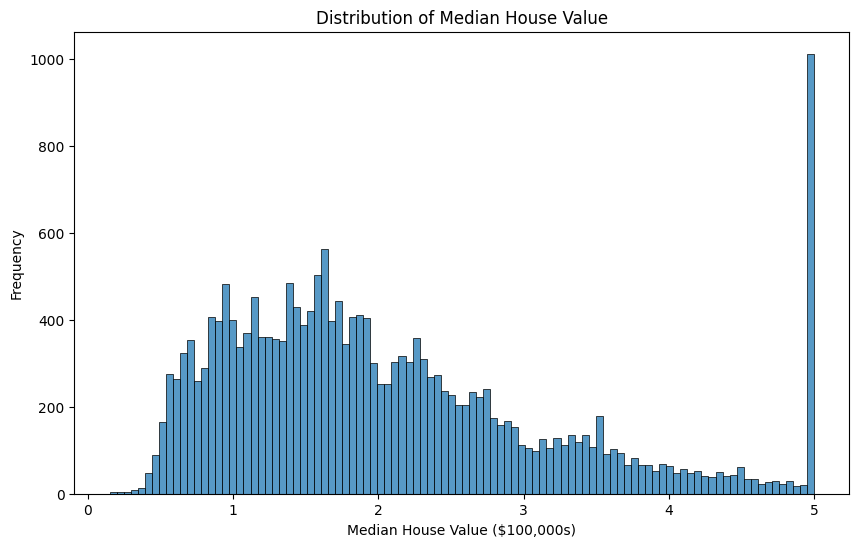

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['MedHouseVal'], bins=100)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Frequency')
plt.show()

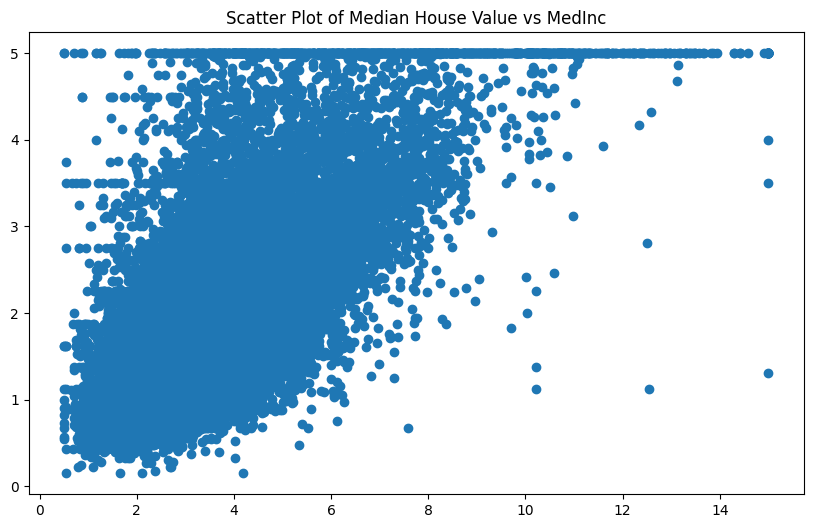

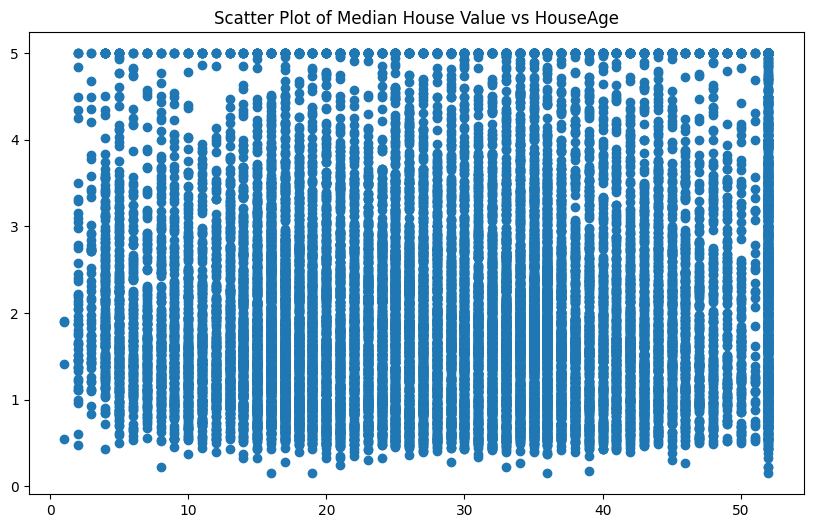

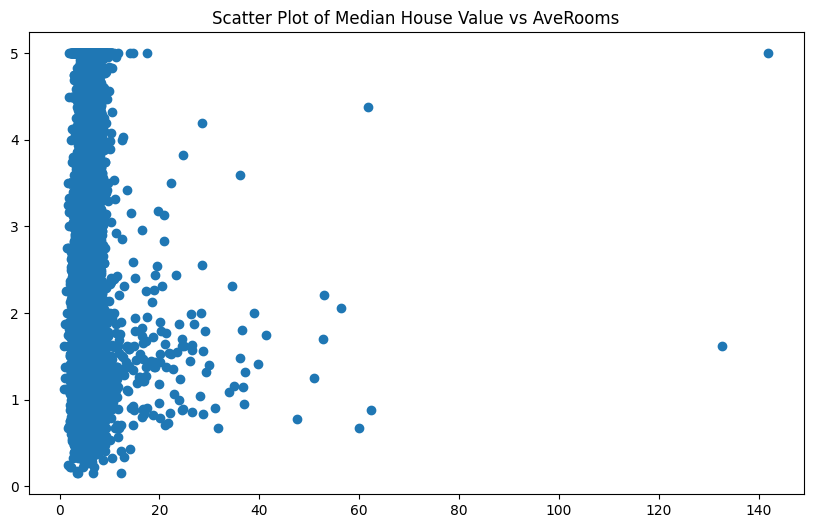

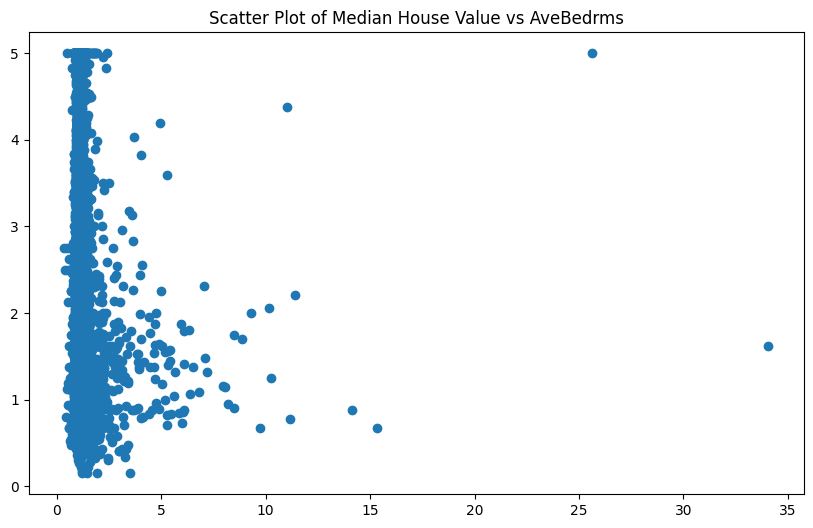

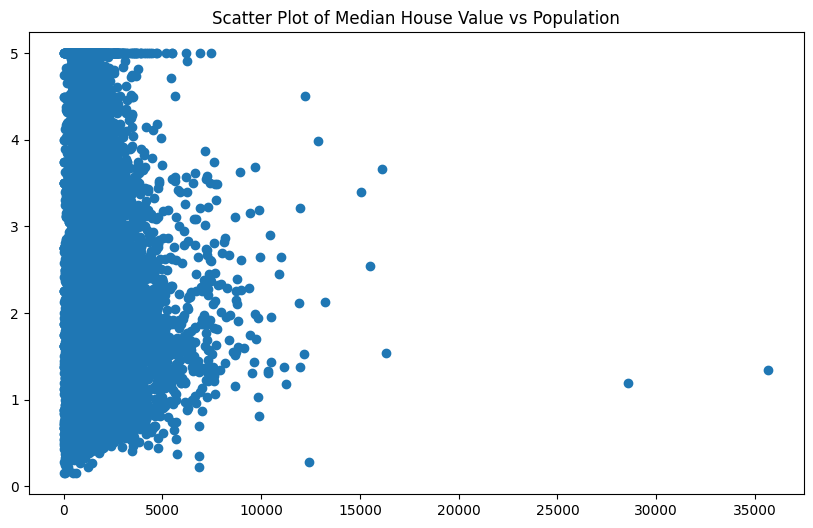

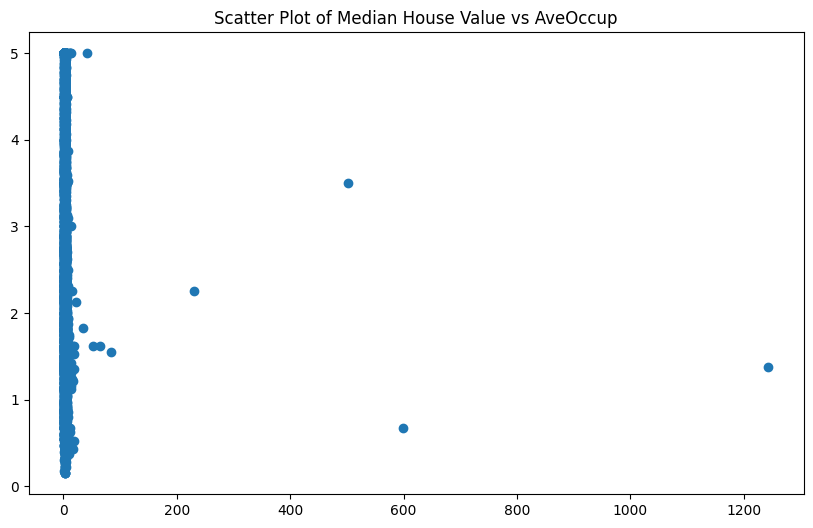

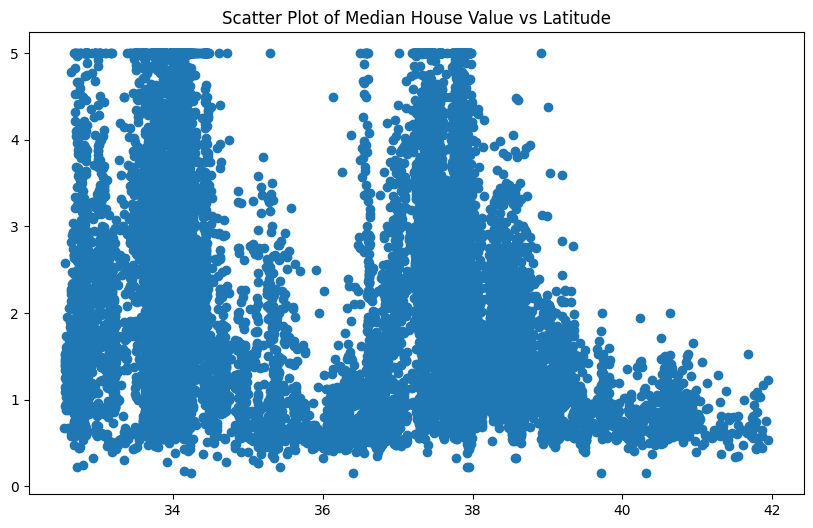

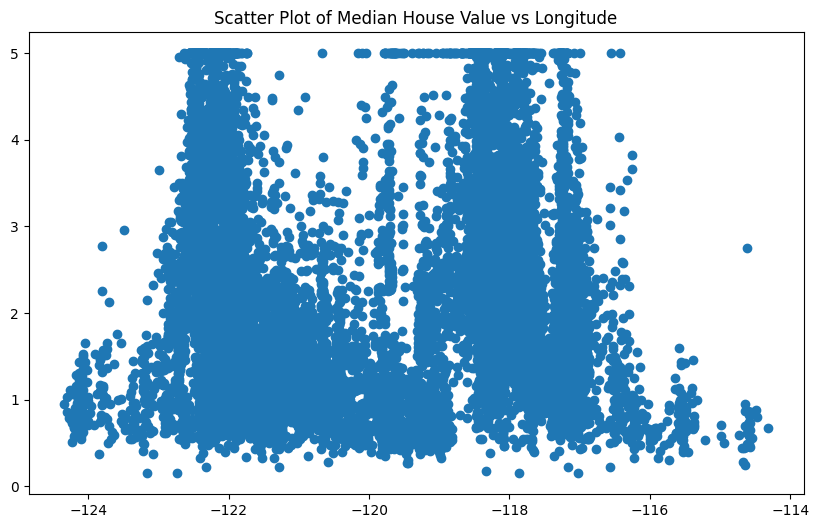

In [ ]:
x = [df['MedInc'], df['HouseAge'], df['AveRooms'], df['AveBedrms'], df['Population'], df['AveOccup'],df['Latitude'], df['Longitude']]
y = df['MedHouseVal']

for i in range(len(x)):
    plt.figure(figsize=(10, 6))
    plt.scatter(x[i], y)
    plt.title(f'Scatter Plot of Median House Value vs {x[i].name}')
    plt.show()

学習データ数: 20630
テストデータ数: 10
------------------------------

【1. 重回帰分析 - 全変数使用】
【係数の95%信頼区間】
                    0          1
const      -38.220528 -35.637353
MedInc       0.428264   0.444716
HouseAge     0.008547   0.010297
AveRooms    -0.118539  -0.095467
AveBedrms    0.588414   0.698705
Population  -0.000013   0.000005
AveOccup    -0.004738  -0.002828
Latitude    -0.435488  -0.407276
Longitude   -0.449201  -0.419669

【2. AIC最小化】
AICで選ばれた変数: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude']

【3. Lasso回帰 (変数選択)】
Lasso最適alpha: 0.0042
Lassoで選ばれた変数: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude']

Lasso係数（0以外）:
     Feature  Lasso Coef
0     MedInc    0.807218
1   HouseAge    0.122061
2   AveRooms   -0.206985
3  AveBedrms    0.247247
5   AveOccup   -0.035314
6   Latitude   -0.854915
7  Longitude   -0.822420

【4. テストデータ(10個)に対する予測精度比較】
重回帰 (全変数): RMSE = 0.9703
AIC最小モデル : RMSE = 0.9700
Lasso回帰     : RMSE = 0.9893


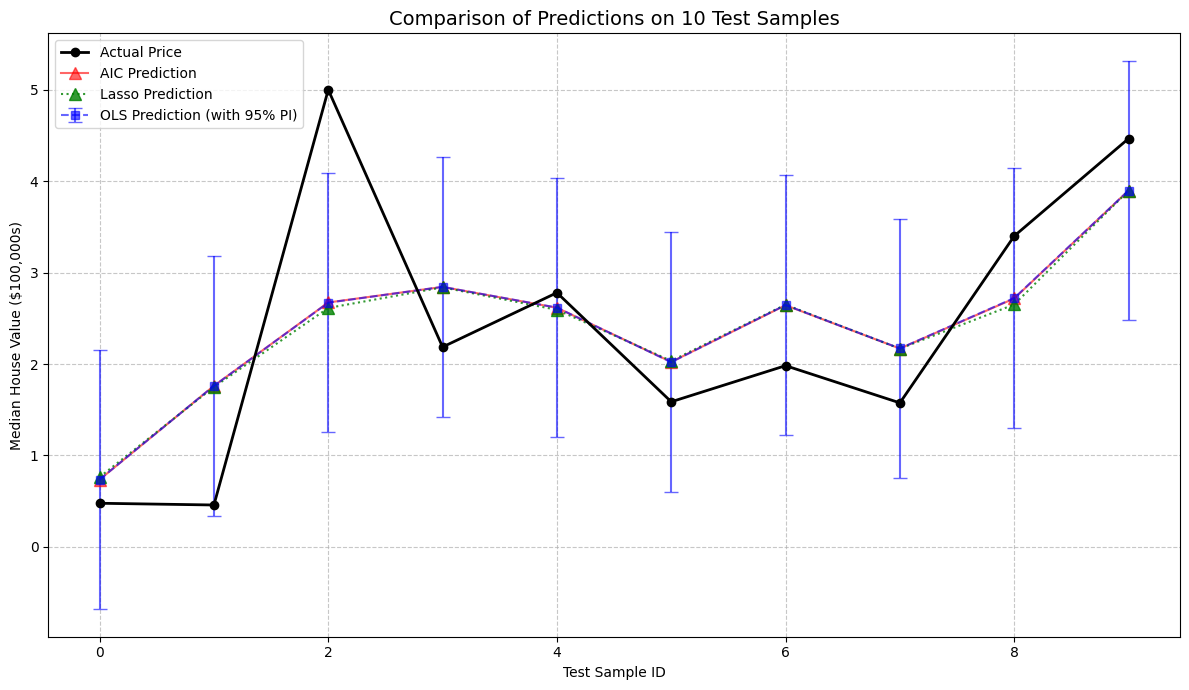

In [ ]:
#10個テストデータを取っておく
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10, random_state=42)

print(f"学習データ数: {len(X_train)}")
print(f"テストデータ数: {len(X_test)}")
print("-" * 30)


#全ての変数で重回帰を行う
print("\n" + "="*50)
print("【1. 重回帰分析 全変数】")
print("="*50)

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model_ols_sm = sm.OLS(y_train, X_train_const).fit()

#テストデータで予測する
pred_res = model_ols_sm.get_prediction(X_test_const)
pred_summary = pred_res.summary_frame(alpha=0.05)
y_pred_ols = pred_res.predicted_mean

#95%信頼区間を出す
print("【係数の95%信頼区間】")
print(model_ols_sm.conf_int())

#AICが最小となるようなモデルを、変数の組を総当たりして出す
print("\n" + "="*50)
print("【2. AIC最小化】")
print("="*50)

best_aic = float('inf')
best_subset = []
n = len(y_train)

for k in range(1, len(X.columns) + 1):
    for combo in itertools.combinations(X.columns, k):
        combo_list = list(combo)
        X_sub = X_train[combo_list]
        model = LinearRegression()
        model.fit(X_sub, y_train)
        rss = np.sum((y_train - model.predict(X_sub)) ** 2)
        k_params = k + 1
        aic = n * np.log(rss/n) + 2 * k_params
        if aic < best_aic:
            best_aic = aic
            best_subset = combo_list

print(f"AICで選ばれた変数: {best_subset}")

#AICを最小するモデルで、テストデータで予測する
model_aic = LinearRegression()
model_aic.fit(X_train[list(best_subset)], y_train)
y_pred_aic = model_aic.predict(X_test[list(best_subset)])


#ラッソ回帰を行う
print("\n" + "="*50)
print("【3. Lasso回帰 】")
print("="*50)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lasso = LassoCV(cv=5, random_state=42)
model_lasso.fit(X_train_scaled, y_train)

#テストデータで予測を行う
y_pred_lasso = model_lasso.predict(X_test_scaled)

lasso_mask = model_lasso.coef_ != 0
lasso_features = X.columns[lasso_mask].tolist()
print(f"Lasso最適alpha: {model_lasso.alpha_:.4f}")
print(f"Lassoで選ばれた変数: {lasso_features}")


lasso_df = pd.DataFrame({
    'Feature': X.columns,
    'Lasso Coef': model_lasso.coef_
})
print("\nLasso係数（0以外）:")
print(lasso_df[lasso_df['Lasso Coef'] != 0])


#予測誤差を出し、比較する
print("\n" + "="*50)
print("【4. テストデータ(10個)に対する予測精度比較】")
print("="*50)

rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
rmse_aic = np.sqrt(mean_squared_error(y_test, y_pred_aic))
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"重回帰 (全変数): RMSE = {rmse_ols:.4f}")
print(f"AIC最小モデル : RMSE = {rmse_aic:.4f}")
print(f"Lasso回帰     : RMSE = {rmse_lasso:.4f}")


plt.figure(figsize=(12, 7))
x_axis = np.arange(10)

#実際のデータの値
plt.plot(x_axis, y_test, 'ko-', label='Actual Price', linewidth=2, zorder=10)

#重回帰の時の予測した値と、信頼区間
lower_error = y_pred_ols - pred_summary['obs_ci_lower']
upper_error = pred_summary['obs_ci_upper'] - y_pred_ols
plt.errorbar(x_axis, y_pred_ols, yerr=[lower_error, upper_error],
             fmt='bs--', label='OLS Prediction (with 95% PI)', alpha=0.6, capsize=5)
#AICとラッソ回帰で予測した値
plt.plot(x_axis, y_pred_aic, 'r^-', label='AIC Prediction', alpha=0.6, markersize=8)
plt.plot(x_axis, y_pred_lasso, 'g^:', label='Lasso Prediction', alpha=0.8, markersize=8)

plt.title('Comparison of Predictions on 10 Test Samples', fontsize=14)
plt.ylabel('Median House Value ($100,000s)')
plt.xlabel('Test Sample ID')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()